In [4]:
import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# **Kaggle config**

In [ ]:
!pip install kaggle

In [6]:
os.makedirs('/root/.kaggle', exist_ok=True)

import shutil
shutil.copy("/kaggle/input/kaggle-json/kaggle.json", "/root/.kaggle/kaggle.json")

'/root/.kaggle/kaggle.json'

In [7]:
!chmod 600 /root/.kaggle/kaggle.json

In [8]:
!kaggle datasets list

ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset   Global Earthquake-Tsunami Risk Assessment Dataset        16151  2025-10-01 16:35:53.273000          12908        453  1.0              
jockeroika/life-style-data                                     Life Style Data                                        3995645  2025-10-14 13:50:45.303000          15196        321  0.8235294        
jaderz/hospital-beds-management                                Hospital Beds Management                                 47583  2025-10-03 09:21:58.590000          10638        275  1.0              
ahmad

In [9]:
output_dir = "/kaggle/working/cleaned_images/"
os.makedirs(output_dir, exist_ok=True)

In [10]:
!kaggle datasets init -p /kaggle/working/cleaned_images/

Data package template written to: /kaggle/working/cleaned_images/dataset-metadata.json


In [11]:
import json

meta_path = "/kaggle/working/cleaned_images/dataset-metadata.json"

# Load and modify metadata
with open(meta_path) as f:
    meta = json.load(f)

meta["title"] = "Skin Lesion Classification - HAM10000"
meta["id"] = "krishu22/skin-lesion-classification-ham10000"
meta["licenses"] = [{"name": "CC0-1.0"}]

# Save it back
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=4)

In [12]:
import numpy as np
import pandas as pd 
import cv2
import matplotlib.pyplot as plt

print("imports successfully done")

imports successfully done


In [13]:
# 1. input image
#path = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026013.jpg"

# 2. Read image
#image = cv2.imread(path, cv2.IMREAD_COLOR) # loads in BGR format

# 3. Image cropping
#cropped_image = image[30:410,30:560] # remove unwanted borders / labels

# **dull razor**

In [14]:
from tqdm import tqdm

In [15]:
data_dir_1 = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/"
data_dir_2 = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/"
output_root = "/kaggle/working/cleaned_images/"

In [16]:
def plot_images(titles, images):
    
    # Convert all to RGB and same height
    rgb_images = []
    h_min = min(img.shape[0] for img in images)  # smallest height
    for img in images:
        if len(img.shape) == 2:  # grayscale → convert to 3-channel
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # resize to same height
        ratio = h_min / img.shape[0]
        img = cv2.resize(img, (int(img.shape[1] * ratio), h_min))
        rgb_images.append(img)

    # Combine all images horizontally
    combined = np.hstack(rgb_images)

    # Add titles on top (optional but neat)
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    thickness = 2
    text_color = (255, 255, 255)

    # Create space for titles
    title_height = 50
    output = np.full((combined.shape[0] + title_height, combined.shape[1], 3), 0, dtype=np.uint8)

    # Copy image content below title area
    output[title_height:, :, :] = combined

    # Write each title roughly above its section
    total_width = combined.shape[1]
    section_widths = [img.shape[1] for img in rgb_images]
    x_offset = 0
    for i, title in enumerate(titles):
        text_size = cv2.getTextSize(title, font, font_scale, thickness)[0]
        text_x = x_offset + (section_widths[i] - text_size[0]) // 2
        text_y = int(title_height * 0.75)
        cv2.putText(output, title, (text_x, text_y), font, font_scale, text_color, thickness)
        x_offset += section_widths[i]

    return output

In [17]:
def DullRazorHairRemoval(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    #cropped_image = image[30:410,30:560] ---> skipped because of loss of info
    grayscale_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(1,(9,9))
    blackhat = cv2.morphologyEx(grayscale_image, cv2.MORPH_BLACKHAT, kernel)
    gaussian_blur_image = cv2.GaussianBlur(blackhat, (3,3), cv2.BORDER_DEFAULT)
    ret, mask = cv2.threshold(gaussian_blur_image, 10, 255, cv2.THRESH_BINARY)
    final_image = cv2.inpaint(image, mask, 6, cv2.INPAINT_TELEA)   
    combined_image = plot_images(
        ["Original", "Grayscale", "Blackhat", "Mask", "Clean"],
        [image, grayscale_image, blackhat, mask, final_image]
    )
    return combined_image, final_image

In [18]:
"""
count = 0
for image_name in os.listdir(data_dir_2):
    if (count == 10):
        break
    if image_name.lower().endswith(".jpg"):
        image_path = os.path.join(data_dir_2, image_name)
        combined_image = DullRazorHairRemoval(image_path)
        image_save_path = os.path.join("/kaggle/working/cleaned_images/", image_name)
        cv2.imwrite(image_save_path, combined_image)
        count += 1

print("cell executed successfully")
"""

"""def process_directory(input_dir):
    folder_name = os.path.basename(os.path.normpath(input_dir))
    save_dir = os.path.join(output_root, folder_name)
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for image_name in os.listdir(input_dir):
        if count == 10:  # limit for test runs
            break
        if image_name.lower().endswith(".jpg"):
            image_path = os.path.join(input_dir, image_name)
            combined_image, final_image = DullRazorHairRemoval(image_path)
            save_path = os.path.join(save_dir, image_name)
            cv2.imwrite(save_path, cv2.cvtColor(combined_image, cv2.COLOR_RGB2BGR))
            count += 1
    print(f"Processed {count} images from {folder_name}")"""

'def process_directory(input_dir):\n    folder_name = os.path.basename(os.path.normpath(input_dir))\n    save_dir = os.path.join(output_root, folder_name)\n    os.makedirs(save_dir, exist_ok=True)\n\n    count = 0\n    for image_name in os.listdir(input_dir):\n        if count == 10:  # limit for test runs\n            break\n        if image_name.lower().endswith(".jpg"):\n            image_path = os.path.join(input_dir, image_name)\n            combined_image, final_image = DullRazorHairRemoval(image_path)\n            save_path = os.path.join(save_dir, image_name)\n            cv2.imwrite(save_path, cv2.cvtColor(combined_image, cv2.COLOR_RGB2BGR))\n            count += 1\n    print(f"Processed {count} images from {folder_name}")'

In [19]:
def process_directory(input_dir):
    folder_name = os.path.basename(os.path.normpath(input_dir))
    save_dir = os.path.join(output_root, folder_name)
    os.makedirs(save_dir, exist_ok=True)
    
    # Get list of jpg files
    jpg_files = [f for f in os.listdir(input_dir) if f.lower().endswith(".jpg")]
    
    # Process with progress bar
    for image_name in tqdm(jpg_files, desc=f"Processing {folder_name}", unit="img"):
        image_path = os.path.join(input_dir, image_name)
        # get both images
        combined_image, final_image = DullRazorHairRemoval(image_path)
        # create folder for this image
        image_base = os.path.splitext(image_name)[0]
        image_folder = os.path.join(save_dir, image_base)
        os.makedirs(image_folder, exist_ok=True)
        # save paths
        combined_path = os.path.join(image_folder, "dull_razor_processing.jpg")
        final_path = os.path.join(image_folder, "dull_razor_output.jpg")
        # save both images
        cv2.imwrite(combined_path, cv2.cvtColor(combined_image, cv2.COLOR_RGB2BGR))
        cv2.imwrite(final_path, final_image)
    
    print(f"Completed {len(jpg_files)} images from {folder_name}")

In [20]:
process_directory(data_dir_1)

Processing HAM10000_images_part_1: 100%|██████████| 5000/5000 [11:24<00:00,  7.31img/s]

Completed 5000 images from HAM10000_images_part_1


In [21]:
process_directory(data_dir_2)

Processing HAM10000_images_part_2: 100%|██████████| 5015/5015 [11:19<00:00,  7.38img/s]

Completed 5015 images from HAM10000_images_part_2


In [22]:
!kaggle datasets create -p /kaggle/working/cleaned_images/ --dir-mode zip

Starting upload for file HAM10000_images_part_1.zip
100%|███████████████████████████████████████| 1.78G/1.78G [00:15<00:00, 125MB/s]
Upload successful: HAM10000_images_part_1.zip (2GB)
Starting upload for file HAM10000_images_part_2.zip
100%|██████████████████████████████████████| 1.77G/1.77G [00:21<00:00, 90.1MB/s]
Upload successful: HAM10000_images_part_2.zip (2GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/krishu22/skin-lesion-classification-ham10000


In [23]:
!kaggle datasets version -p /kaggle/working/cleaned_images/ --dir-mode zip -m "dullrazor done"

Starting upload for file HAM10000_images_part_1.zip
100%|███████████████████████████████████████| 1.78G/1.78G [00:13<00:00, 141MB/s]
Upload successful: HAM10000_images_part_1.zip (2GB)
Starting upload for file HAM10000_images_part_2.zip
100%|███████████████████████████████████████| 1.77G/1.77G [00:17<00:00, 108MB/s]
Upload successful: HAM10000_images_part_2.zip (2GB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krishu22/skin-lesion-classification-ham10000


In [24]:
!kaggle datasets list --user krishu22

ref                                           title                                        size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------  -------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
krishu22/simple-logistic-regression           Simple Logistic Regression                  45809  2025-01-28 15:07:01.790000             55          1  1.0              
krishu22/diabetes-dataset                     Diabetes Dataset                             9045  2025-02-09 15:56:32.890000            473          2  1.0              
krishu22/google-drive-credentials             google-drive-credentials                     1846  2025-10-04 15:38:17.990000              0          0  0.125            
krishu22/kaggle-json                          kaggle.json                                   227  2025-10-14 04:50:50.627000              0          0  0.12

# **segmentation**

In [39]:
from pathlib import Path
from tqdm import tqdm
import numpy as np
import os
import cv2

print("cell executed.")

cell executed.


In [44]:
class SegmentationProcessor:
    
    def __init__(self, masks_dir: str, output_size: tuple = (224, 224)):
        self.masks_dir = Path(masks_dir)
        self.output_size = output_size
    
    def get_mask(self, image_id: str) -> np.ndarray:
        mask_path = self.masks_dir / f"{image_id}_segmentation.png"
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        return mask
    
    def apply_mask_white_bg(self, image: np.ndarray, mask: np.ndarray) -> np.ndarray:
        
        if mask.shape != image.shape[:2]: # Ensure mask matches image size
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]))
    
        coords = np.where(mask > 0) # find lesion region from mask

        if len(coords[0]) == 0: # if no lesion found, return original
            return image
    
        # get bounding box w padding
        y_min = max(0, coords[0].min() - 20)
        y_max = min(image.shape[0], coords[0].max() + 20)
        x_min = max(0, coords[1].min() - 20)
        x_max = min(image.shape[1], coords[1].max() + 20)
    
        cropped = image[y_min:y_max, x_min:x_max] # crop to lesion region 
        return cropped # return output

    def resize_preserve_aspect_ratio(self, image: np.ndarray) -> np.ndarray:
    
        h, w = image.shape[:2]
        target_h, target_w = self.output_size
    
        # calc scale to fit image within target size
        scale = min(target_w / w, target_h / h)
    
        # new dimensions after scaling (maintains aspect ratio)
        new_w = int(w * scale)
        new_h = int(h * scale)
    
        resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4) # resize 
        canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8) # create black canvas (zero-padding)
    
        # center the resized image on canvas
        pad_y = (target_h - new_h) // 2
        pad_x = (target_w - new_w) // 2
    
        canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized # place image on canvas
    
        return canvas
    
    def segment_image(self, image: np.ndarray, mask: np.ndarray) -> np.ndarray:
        cropped = self.apply_mask_white_bg(image, mask)
        final = self.resize_preserve_aspect_ratio(cropped) # resize with aspect ratio preservation + zero-padding
        return final


print("cell executed..")

cell executed..


In [45]:
class HAM10000SegmentationPipeline:  
    
    def __init__(self, masks_dir: str, output_size: tuple = (224, 224)):
        self.processor = SegmentationProcessor(masks_dir, output_size)
        self.output_size = output_size
        self.stats = {
            'processed': 0, 
            'skipped': 0, 
            'failed': 0}
    
    def process_image(self, image_folder: str, image_id: str, 
                 output_dir: str) -> bool:
        try:
            image_path = os.path.join(image_folder, "dull_razor_output.jpg") # read from input
            
            image = cv2.imread(image_path) # failed
            if image is None:
                self.stats['failed'] += 1
                return False

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
            mask = self.processor.get_mask(image_id) # skipped
            if mask is None:
                self.stats['skipped'] += 1
                return False
    
            segmented = self.processor.segment_image(image, mask)
        
            os.makedirs(output_dir, exist_ok=True)  # ensure output folder exists
            output_path = os.path.join(output_dir, "segmented.jpg")
            cv2.imwrite(output_path, cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))

            self.stats['processed'] += 1
            return True
    
        except Exception as e:
            exc = str(e)
            print(f"Error processing {image_id}: {exc}")
            self.stats['failed'] += 1
            return False
    
    def process_directory(self, input_dir: str, output_dir: str, 
                         show_progress: bool = True):

        input_path = Path(input_dir)
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)
        
        image_id_folders = [d for d in input_path.iterdir()   # all image folders containing dull_razor_output.jpg
                        if d.is_dir() and (d / "dull_razor_output.jpg").exists()]
        
        if not image_id_folders:
            print(f"no folders found..")
            return

        lenn = len(image_id_folders)
        print(f"\nprocessing {lenn} images from {input_dir}...")

        folder_name = Path(input_dir).name  # Get folder name (e.g., "HAM10000_images_part_1")
        iterator = tqdm(image_id_folders, disable=not show_progress, 
                        desc=f"Segmenting {folder_name}", unit="img")
        
        for image_folder in iterator:
            image_id = image_folder.name  # e.g., 'ISIC_0024306'
            seg_output_dir = output_path / image_id # create corresponding output folder
            self.process_image(str(image_folder), image_id, str(seg_output_dir)) # processing part
        
        # print stats
        print(f"\nsegmentation complete!")
        print(f"processed: {self.stats['processed']}")
        print(f"skipped (no mask): {self.stats['skipped']}")
        print(f"failed: {self.stats['failed']}")

print("cell executed")

cell executed


In [46]:
input_root = "/kaggle/input/skin-lesion-classification-ham10000/" 
masks_dir = "/kaggle/input/ham10000-lesion-segmentations/HAM10000_segmentations_lesion_tschandl/"
working_root = "/kaggle/working/cleaned_images/"  

In [47]:
# Initialize 
pipeline = HAM10000SegmentationPipeline(masks_dir=masks_dir, output_size=(224, 224))

print("\nsegmenting part_1 images...")
pipeline.process_directory(
    input_dir=os.path.join(input_root, "HAM10000_images_part_1"),
    output_dir=os.path.join(working_root, "HAM10000_images_part_1") 
)


segmenting part_1 images...

processing 5000 images from /kaggle/input/skin-lesion-classification-ham10000/HAM10000_images_part_1...


Segmenting HAM10000_images_part_1: 100%|██████████| 5000/5000 [08:37<00:00,  9.65img/s]


segmentation complete!
processed: 5000
skipped (no mask): 0
failed: 0


In [48]:
pipeline.stats = {'processed': 0, 'skipped': 0, 'failed': 0}
    
print("\nsegmenting part_2 images...")
pipeline.process_directory(
    input_dir=os.path.join(input_root, "HAM10000_images_part_2"),
    output_dir=os.path.join(working_root, "HAM10000_images_part_2")  
)


segmenting part_2 images...

processing 5015 images from /kaggle/input/skin-lesion-classification-ham10000/HAM10000_images_part_2...


Segmenting HAM10000_images_part_2: 100%|██████████| 5015/5015 [07:53<00:00, 10.58img/s]


segmentation complete!
processed: 5015
skipped (no mask): 0
failed: 0


In [49]:
print("------------------ segmentation complete finallyyyayayy ------------------")

------------------ segmentation complete finallyyyayayy ------------------


In [50]:
total_processed = pipeline.stats['processed']
print(f"total processed: {total_processed}")

total processed: 5015


In [51]:
print("updating help dataset.. ")

!kaggle datasets version -p /kaggle/working/cleaned_images/ --dir-mode zip -m "added segmented images"

print("dataset updated successfully..")

updating help dataset.. 
Starting upload for file HAM10000_images_part_1.zip
100%|██████████████████████████████████████| 1.85G/1.85G [00:24<00:00, 79.6MB/s]
Upload successful: HAM10000_images_part_1.zip (2GB)
Starting upload for file HAM10000_images_part_2.zip
100%|██████████████████████████████████████| 1.84G/1.84G [00:21<00:00, 92.9MB/s]
Upload successful: HAM10000_images_part_2.zip (2GB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krishu22/skin-lesion-classification-ham10000
dataset updated successfully..


# **metadata preprocessing**

In [52]:
df = pd.read_csv("/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [53]:
print(max(df['age']))
print(min(df['age']))

85.0
0.0


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


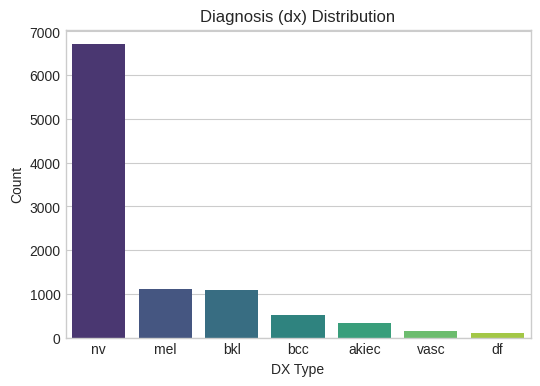

In [55]:
print(df['dx'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='dx', data=df, order=df['dx'].value_counts().index, palette="viridis")
plt.title("Diagnosis (dx) Distribution")
plt.xlabel("DX Type")
plt.ylabel("Count")
plt.show()

dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64


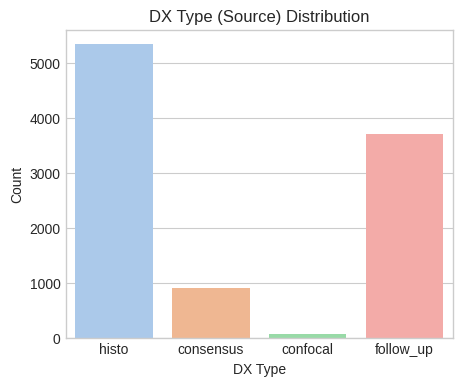

In [56]:
print(df['dx_type'].value_counts())
plt.figure(figsize=(5,4))
sns.countplot(x='dx_type', data=df, palette="pastel")
plt.title("DX Type (Source) Distribution")
plt.xlabel("DX Type")
plt.ylabel("Count")
plt.show()

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


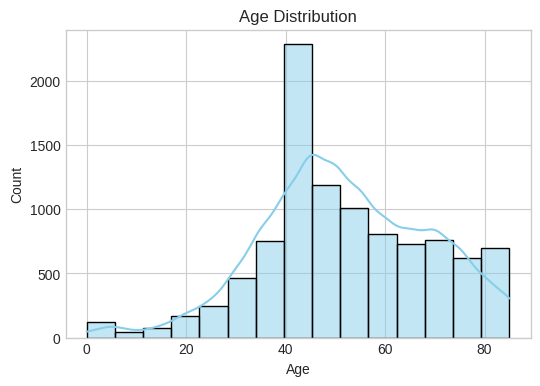

In [57]:
print(df['age'].describe())
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=15, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [58]:
print(df['age'].value_counts().sort_index())

age
0.0       39
5.0       86
10.0      41
15.0      77
20.0     169
25.0     247
30.0     464
35.0     753
40.0     985
45.0    1299
50.0    1187
55.0    1009
60.0     803
65.0     731
70.0     756
75.0     618
80.0     404
85.0     290
Name: count, dtype: int64


sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


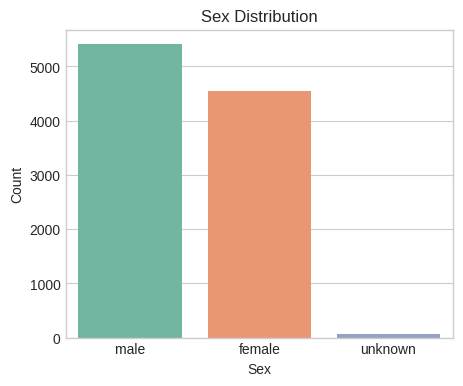

In [59]:
print(df['sex'].value_counts())
plt.figure(figsize=(5,4))
sns.countplot(x='sex', data=df, palette="Set2")
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64


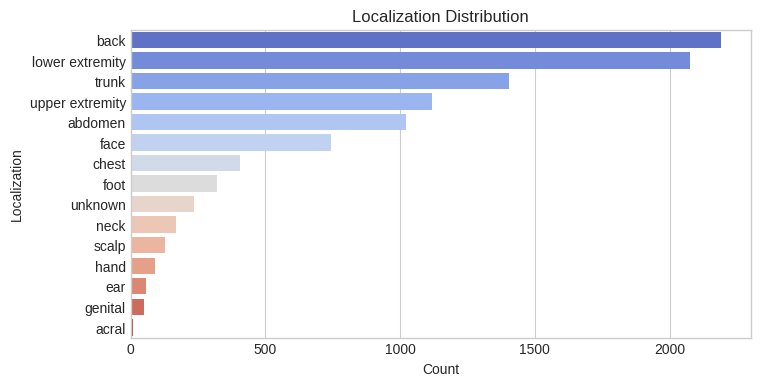

In [60]:
print(df['localization'].value_counts())
plt.figure(figsize=(8,4))
sns.countplot(y='localization', data=df, order=df['localization'].value_counts().index, palette="coolwarm")
plt.title("Localization Distribution")
plt.xlabel("Count")
plt.ylabel("Localization")
plt.show()

In [61]:
from sklearn.preprocessing import MinMaxScaler

In [62]:
# age - normalized - 2d
age_filled = df['age'].fillna(df['age'].median())
df['age_normalized'] = MinMaxScaler().fit_transform(age_filled.values.reshape(-1, 1))
df['age_is_missing'] = df['age'].isna().astype(int)

In [63]:
# Sex - 1hot - 2d
sex_onehot = pd.DataFrame({
    'sex_female': (df['sex'] == 'female').astype(int),
    'sex_male': (df['sex'] == 'male').astype(int)
})

In [64]:
# localization - 1hot - 14d
df['localization'] = df['localization'].str.replace(' ', '_')
localization_onehot = pd.get_dummies(df['localization'], drop_first=False)
localization_onehot.columns = [f"loc_{col}" for col in localization_onehot.columns]

In [ ]:
# labels - onehot - 7d
label_mapping = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 
                 'akiec': 4, 'vasc': 5, 'df': 6}
df['label'] = df['dx'].map(label_mapping)
labels_onehot = pd.get_dummies(df['label'], drop_first=False)
labels_onehot.columns = [f"label_{col}" for col in labels_onehot.columns]

In [66]:
# combined..
metadata_features = np.concatenate([
    df[['age_normalized']].values,
    df[['age_is_missing']].values,
    sex_onehot.values,
    localization_onehot.values
], axis=1)

print("Metadata feature matrix shape:", metadata_features.shape)

Metadata feature matrix shape: (10015, 19)


In [67]:
metadata_df = pd.concat([
    df[['age_normalized', 'age_is_missing']],
    sex_onehot,
    localization_onehot,
    labels_onehot
], axis=1)

combined_df = pd.concat([
    df[['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']],
    metadata_df
], axis=1)

In [68]:
combined_df.to_csv("/kaggle/working/cleaned_images/combined_metadata.csv", index=False)
print("CSV saved successfully")

CSV saved successfully


In [69]:
!kaggle datasets version -p /kaggle/working/cleaned_images/ --dir-mode zip -m "added metadata csv"

Starting upload for file HAM10000_images_part_1.zip
100%|███████████████████████████████████████| 1.85G/1.85G [00:18<00:00, 105MB/s]
Upload successful: HAM10000_images_part_1.zip (2GB)
Starting upload for file HAM10000_images_part_2.zip
100%|███████████████████████████████████████| 1.84G/1.84G [00:19<00:00, 101MB/s]
Upload successful: HAM10000_images_part_2.zip (2GB)
Starting upload for file combined_metadata.csv
100%|██████████████████████████████████████| 2.01M/2.01M [00:00<00:00, 4.49MB/s]
Upload successful: combined_metadata.csv (2MB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krishu22/skin-lesion-classification-ham10000


In [70]:
print("Age (normalized):\n", df['age_normalized'].head(), "\n")
print("Sex one-hot encoded:\n", sex_onehot.head(), "\n")
print("Localization one-hot encoded:\n", localization_onehot.head(), "\n")
print("Labels (mapped):\n", df[['dx', 'label']].head(), "\n")
print("Labels one-hot encoded:\n", labels_onehot.head(), "\n")
print("Metadata feature matrix shape:", metadata_features.shape, "\n")

Age (normalized):
 0    0.941176
1    0.941176
2    0.941176
3    0.941176
4    0.882353
Name: age_normalized, dtype: float64 

Sex one-hot encoded:
    sex_female  sex_male
0           0         1
1           0         1
2           0         1
3           0         1
4           0         1 

Localization one-hot encoded:
    loc_abdomen  loc_acral  loc_back  loc_chest  loc_ear  loc_face  loc_foot  \
0        False      False     False      False    False     False     False   
1        False      False     False      False    False     False     False   
2        False      False     False      False    False     False     False   
3        False      False     False      False    False     False     False   
4        False      False     False      False     True     False     False   

   loc_genital  loc_hand  loc_lower_extremity  loc_neck  loc_scalp  loc_trunk  \
0        False     False                False     False       True      False   
1        False     False            

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


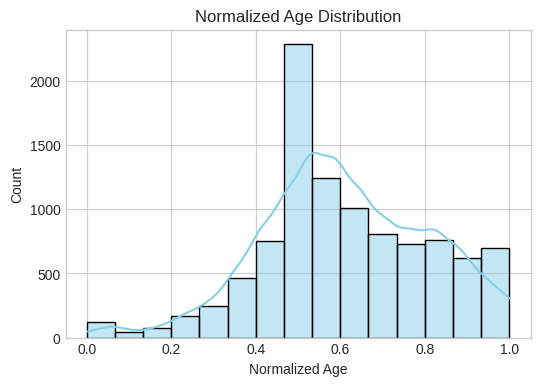

In [71]:
# age
plt.figure(figsize=(6,4))
sns.histplot(df['age_normalized'], bins=15, kde=True, color='skyblue')
plt.title("Normalized Age Distribution")
plt.xlabel("Normalized Age")
plt.ylabel("Count")
plt.show()

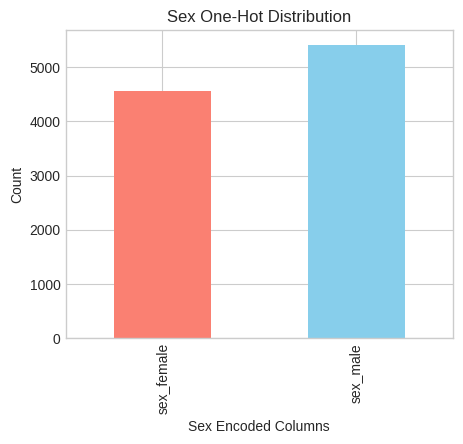

In [72]:
# gender
plt.figure(figsize=(5,4))
sex_onehot.sum().plot(kind='bar', color=['salmon', 'skyblue', 'lightgreen'])
plt.title("Sex One-Hot Distribution")
plt.xlabel("Sex Encoded Columns")
plt.ylabel("Count")
plt.show()

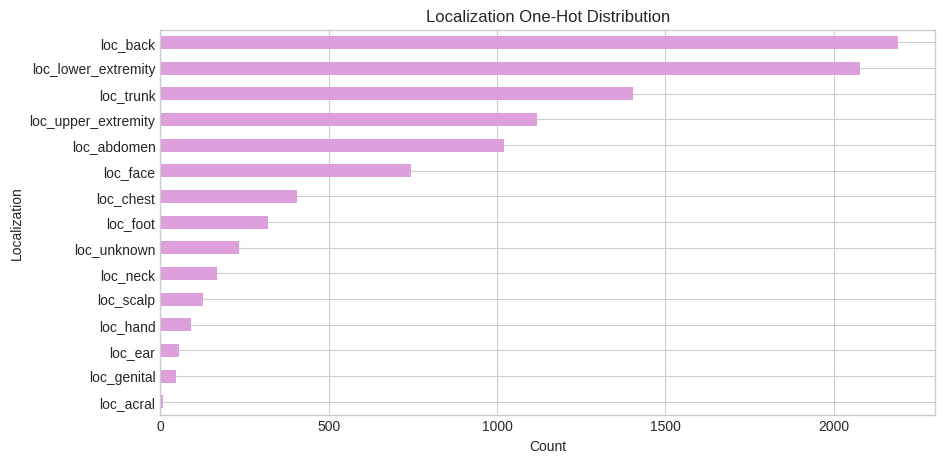

In [73]:
# loc
plt.figure(figsize=(10,5))
localization_onehot.sum().sort_values().plot(kind='barh', color='plum')
plt.title("Localization One-Hot Distribution")
plt.xlabel("Count")
plt.ylabel("Localization")
plt.show()

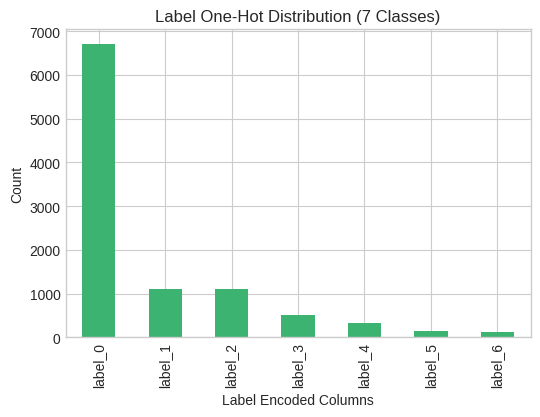

In [74]:
# dx
plt.figure(figsize=(6,4))
labels_onehot.sum().plot(kind='bar', color='mediumseagreen')
plt.title("Label One-Hot Distribution (7 Classes)")
plt.xlabel("Label Encoded Columns")
plt.ylabel("Count")
plt.show()

In [75]:
print(metadata_features[:5])

[[0.94117647 0.         0.         1.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.
  0.        ]
 [0.94117647 0.         0.         1.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.
  0.        ]
 [0.94117647 0.         0.         1.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.
  0.        ]
 [0.94117647 0.         0.         1.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.
  0.        ]
 [0.88235294 0.         0.         1.         0.         0.
  0.         0.         1.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]]
